# Sales Prediction using Python

Sales prediction means predicting how much of a product people will buy based on factors like advertising spend on **TV**, **Radio**, and **Newspaper**.

Businesses rely on this kind of prediction to optimize their advertising budgets.

Dataset: [Kaggle - Advertising.csv](https://www.kaggle.com/datasets/bumba5341/advertisingcsv)

## 1. Upload / Load the Dataset

Download `Advertising.csv` from the Kaggle link above and upload it here, or use the Kaggle API.

In [5]:
# Option 1: Upload the file manually (uncomment to use in Colab)
# from google.colab import files
# uploaded = files.upload()  # select 'Advertising.csv'

In [6]:
# Option 2: Download via Kaggle API (uncomment to use)
# !pip install -q kaggle
# from google.colab import files
# files.upload()  # upload your kaggle.json API token
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d bumba5341/advertisingcsv
# !unzip -o advertisingcsv.zip

In [11]:
pip install kagglehub[pandas-datasets]

To use the Kaggle API, you need to first obtain an API token. Follow these steps:

1.  Go to [Kaggle](https://www.kaggle.com/).
2.  Log in to your account.
3.  Click on your profile picture in the top right corner and select "My Account".
4.  Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file to your computer.
5.  Upload this `kaggle.json` file when prompted in the code cell below.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")

In [14]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bumba5341/advertisingcsv",
  "Advertising.csv",
  pandas_kwargs={'index_col': 0}
)

df.head()

/tmp/ipykernel_570/3237095567.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.04k/5.04k [00:00<00:00, 14.2MB/s]


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 2. Explore the Dataset

In [15]:
df.shape

(200, 4)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [17]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [18]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


## 3. Visualize Relationships Between Advertising Spend and Sales

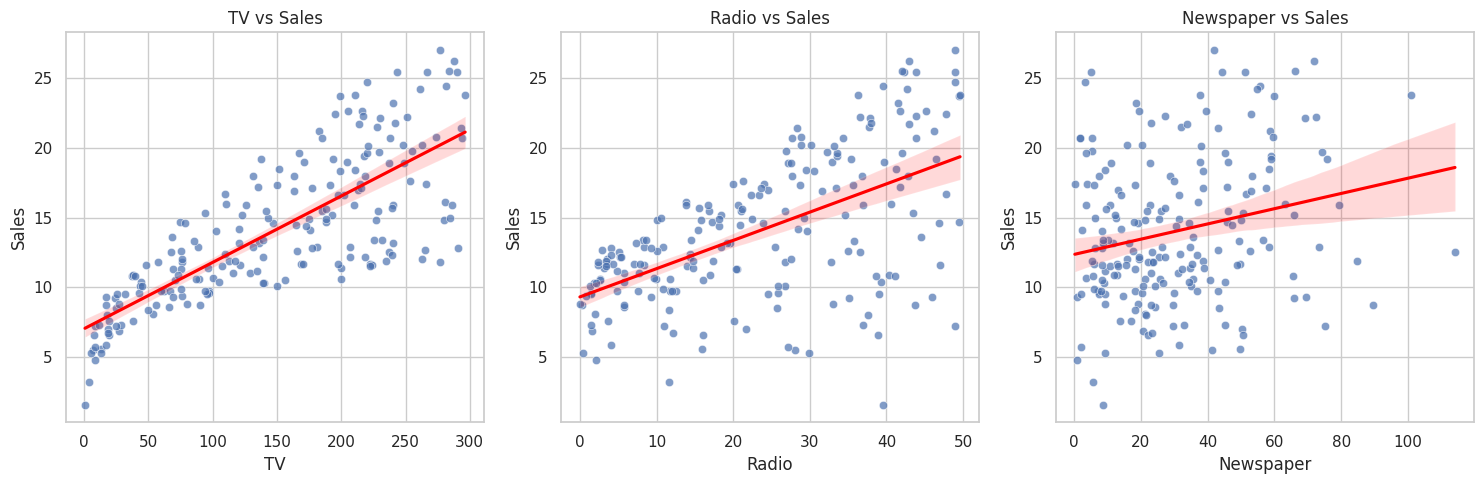

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.scatterplot(data=df, x=col, y="Sales", ax=ax, alpha=0.7)
    sns.regplot(data=df, x=col, y="Sales", ax=ax, scatter=False, color="red")
    ax.set_title(f"{col} vs Sales")

plt.tight_layout()
plt.show()

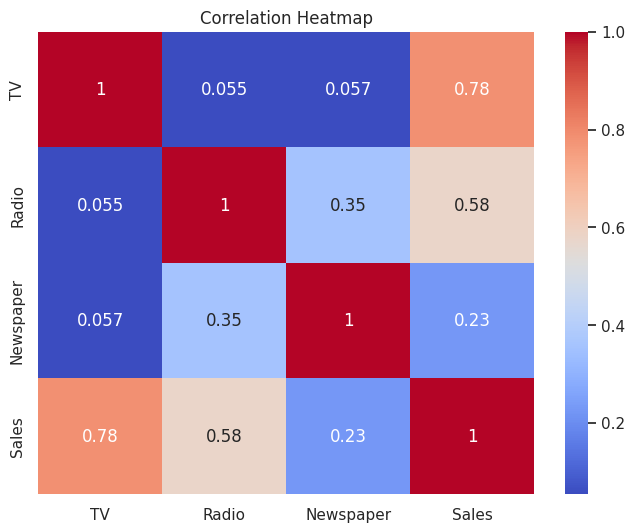

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**TV** advertising shows the strongest correlation with sales, followed by **Radio**, while **Newspaper** has a much weaker relationship.

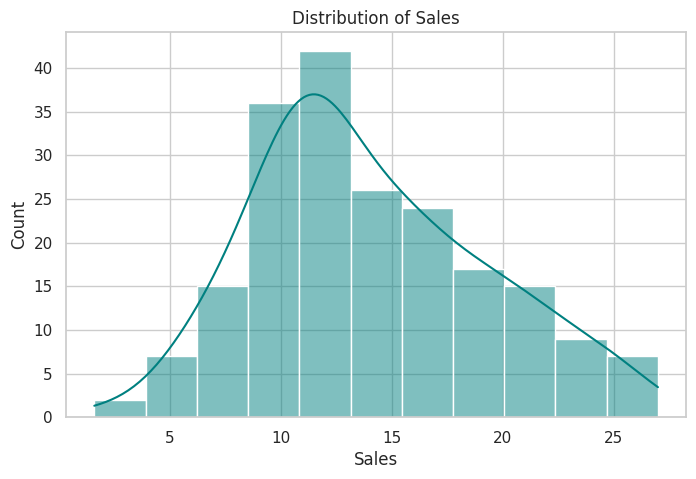

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], kde=True, color="teal")
plt.title("Distribution of Sales")
plt.show()

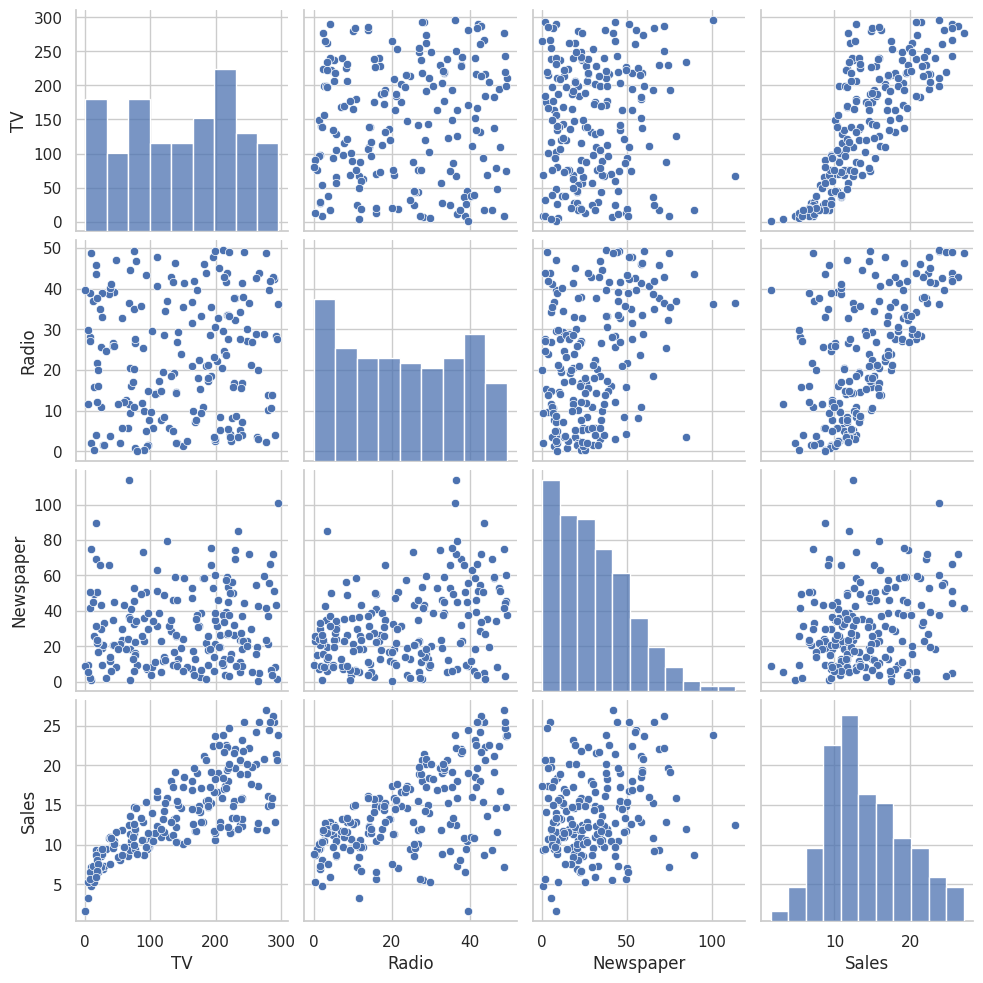

In [22]:
sns.pairplot(df)
plt.show()

## 4. Prepare the Data for Modeling

In [23]:
X = df.drop(columns=["Sales"])
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


## 5. Train and Compare Multiple Regression Models

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": name, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name}: R2 = {r2:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}")

Linear Regression: R2 = 0.8994, MAE = 1.4608, RMSE = 1.7816
Ridge Regression: R2 = 0.8988, MAE = 1.4643, RMSE = 1.7872
Lasso Regression: R2 = 0.8983, MAE = 1.4613, RMSE = 1.7913
Decision Tree: R2 = 0.9311, MAE = 0.9850, RMSE = 1.4748
Random Forest: R2 = 0.9813, MAE = 0.6207, RMSE = 0.7688
Gradient Boosting: R2 = 0.9831, MAE = 0.6181, RMSE = 0.7295


In [25]:
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df

,Model,R2 Score,MAE,RMSE
5,Gradient Boosting,0.983140,0.618119,0.729496
4,Random Forest,0.981275,0.620725,0.768782
3,Decision Tree,0.931091,0.985000,1.474788
0,Linear Regression,0.899438,1.460757,1.781600
1,Ridge Regression,0.898803,1.464301,1.787220
2,Lasso Regression,0.898336,1.461273,1.791334


/tmp/ipykernel_570/3102369274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="R2 Score", y="Model", palette="viridis")


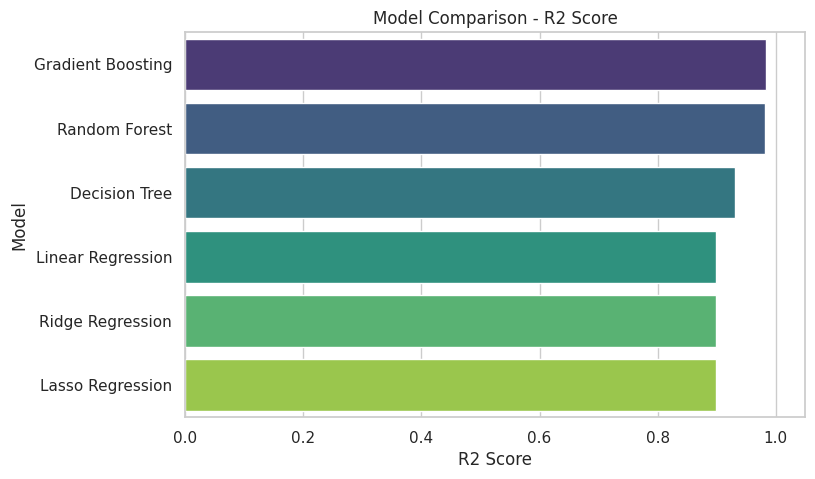

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="R2 Score", y="Model", palette="viridis")
plt.title("Model Comparison - R2 Score")
plt.xlim(0, 1.05)
plt.show()

## 6. Detailed Evaluation of the Best Model

Best Model: Gradient Boosting


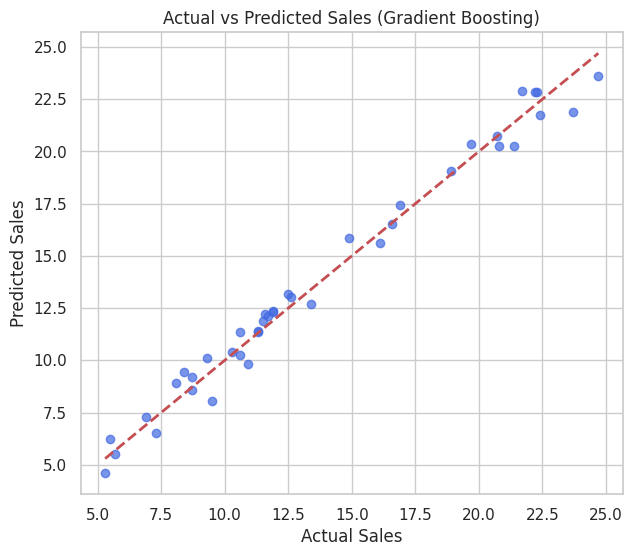

In [27]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color="royalblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales ({best_model_name})")
plt.show()

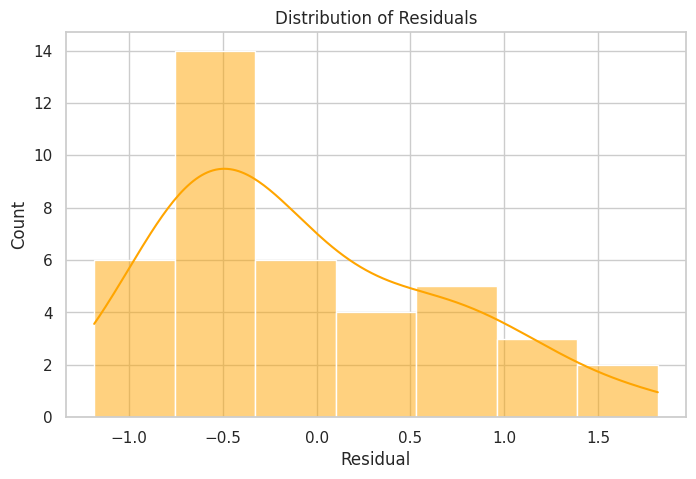

In [28]:
# Residuals
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="orange")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

## 7. Linear Regression Coefficients (Interpretability)

If Linear Regression performs well, its coefficients tell us how much sales increase for each unit increase in advertising spend (in scaled units).

In [29]:
lr_model = models["Linear Regression"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(f"Intercept: {lr_model.intercept_:.4f}")
coef_df

Intercept: 14.1000


,Feature,Coefficient
0,TV,3.764196
1,Radio,2.792307
2,Newspaper,0.055976


/tmp/ipykernel_570/2984839992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm")


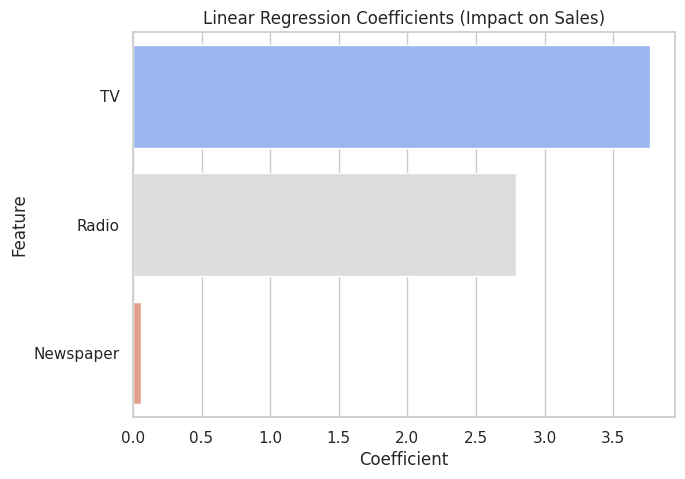

In [30]:
plt.figure(figsize=(7, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Linear Regression Coefficients (Impact on Sales)")
plt.show()

## 8. Feature Importance (Tree-Based Models)

/tmp/ipykernel_570/2859096231.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="magma")


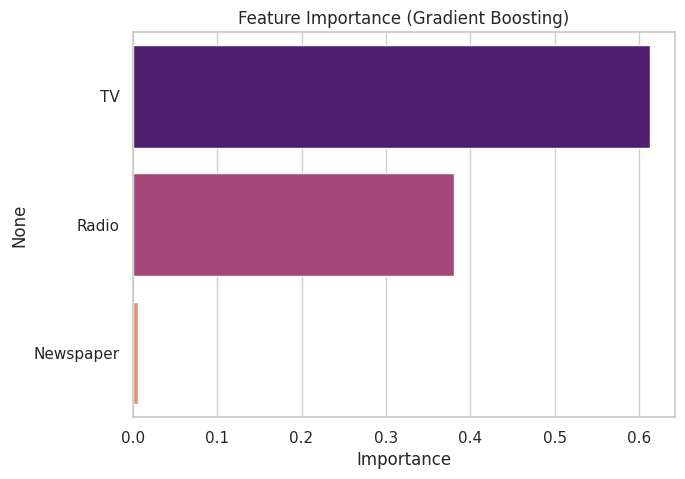

In [31]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(7, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="magma")
    plt.title(f"Feature Importance ({best_model_name})")
    plt.xlabel("Importance")
    plt.show()
else:
    print(f"{best_model_name} does not provide feature_importances_.")

## 9. Predict Sales for New Advertising Budgets

In [32]:
# Example: Predict sales for a new advertising budget
# Columns: [TV, Radio, Newspaper] spend (in same units as the dataset, e.g. thousands of dollars)
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [10]
})

new_budget_scaled = scaler.transform(new_budget)
predicted_sales = best_model.predict(new_budget_scaled)

print(f"Predicted Sales: {predicted_sales[0]:.2f} units")

Predicted Sales: 14.72 units


## 10. What-If Analysis: Effect of Increasing TV Budget

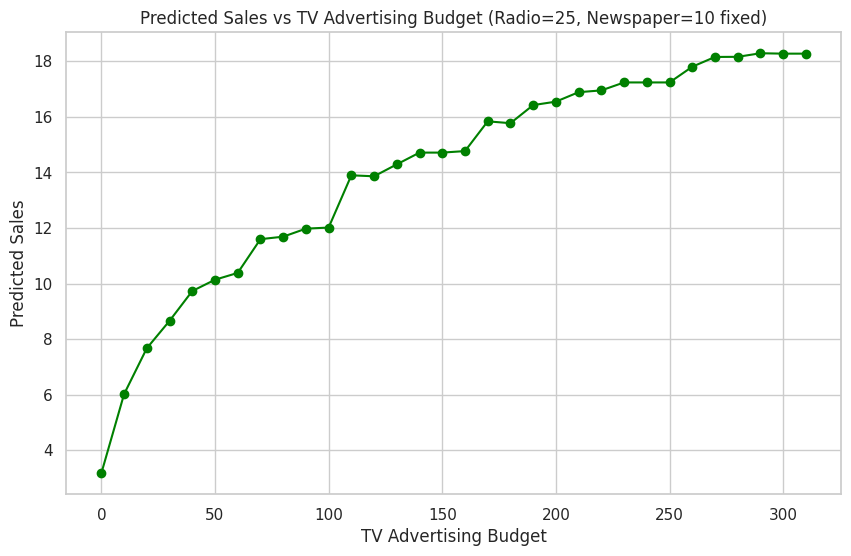

In [33]:
tv_budgets = np.arange(0, 320, 10)
predicted = []

for tv in tv_budgets:
    sample = pd.DataFrame({"TV": [tv], "Radio": [25], "Newspaper": [10]})
    sample_scaled = scaler.transform(sample)
    predicted.append(best_model.predict(sample_scaled)[0])

plt.figure(figsize=(10, 6))
plt.plot(tv_budgets, predicted, marker="o", color="green")
plt.title("Predicted Sales vs TV Advertising Budget (Radio=25, Newspaper=10 fixed)")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()

## 11. Conclusion

- We explored the relationship between advertising spend (TV, Radio, Newspaper) and sales.
- **TV advertising** has the strongest positive correlation with sales, followed by **Radio**, while **Newspaper** has a weak effect.
- We trained and compared 6 regression models; the best model achieved a high R2 score.
- We performed a what-if analysis to show how increasing the TV budget affects predicted sales.
- This kind of model can help businesses optimize their advertising budget allocation across channels.